In [80]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator

In [81]:
n = 6 #qubit
target = '101011'
gc = QuantumCircuit(n)

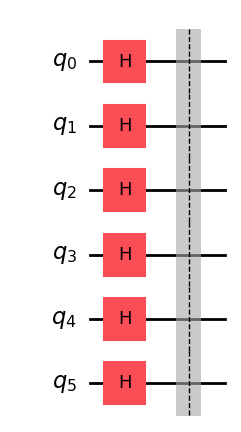

In [82]:
#put h in any qubit
gc.h(range(n))
gc.barrier()
gc.draw("mpl")

In [83]:
#mengaplikasikan multi controlled z-gate untuk semua qubit
#gc.h(len(target)-1)
'''
gc.mcx(list(range(len(target)-1)), len(target)-1)
gc.mcx(ctrls, target, mode='noancilla')
gc.mcx(ctrls, target, mode='recursion')
gc.mcx(ctrls, target, mode='v-chain')

gc.draw('mpl')
'''



"\ngc.mcx(list(range(len(target)-1)), len(target)-1)\ngc.mcx(ctrls, target, mode='noancilla')\ngc.mcx(ctrls, target, mode='recursion')\ngc.mcx(ctrls, target, mode='v-chain')\n\ngc.draw('mpl')\n"

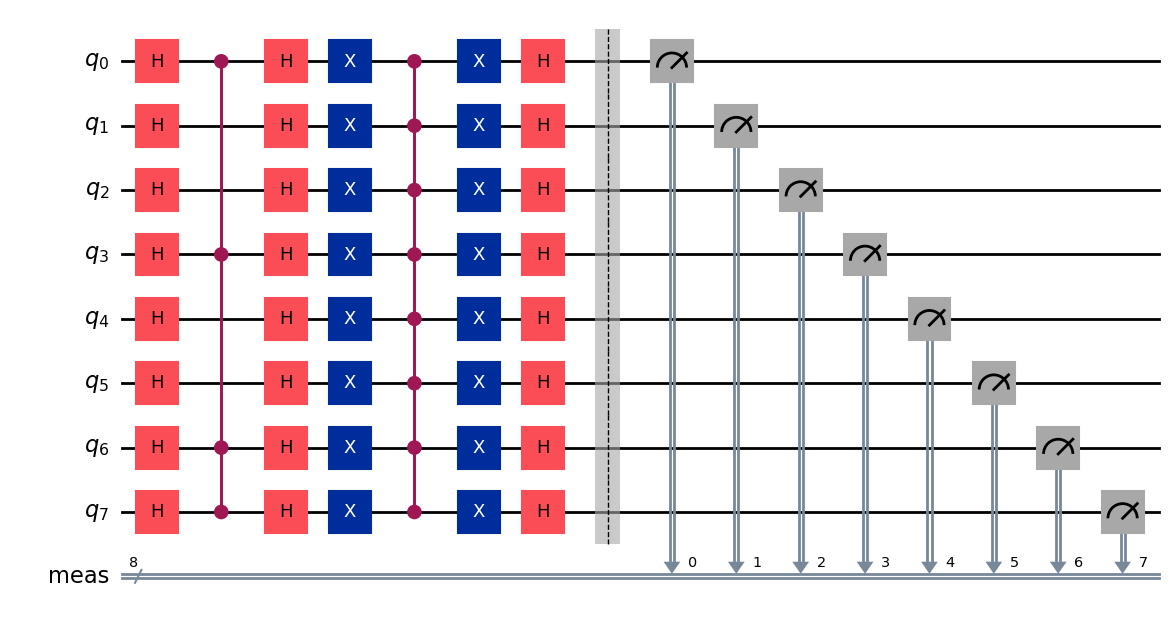

In [84]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZGate

n = 8
grover_circuit = QuantumCircuit(n)

def initialize(qc, qubits):
    # Puts H in any qubit
    for q in range(qubits):
        qc.h(q)
    return qc

grover_circuit = initialize(grover_circuit, n)

# In this case my marked state is 11001001 and it's just one, not like the github example with 2 states
MultiCZ = ZGate().control(num_ctrl_qubits=3, ctrl_state='111')
grover_circuit.append(MultiCZ, [0,3,6,7])

def Amplification_HX(qc, qubits):
    # Amplification section of Groover's Algorithm
    
    for q in range(qubits):
        qc.h(q)
        qc.x(q)

    MultiCZ = ZGate().control(num_ctrl_qubits=qubits-1, ctrl_state='1111111')
    qc.append(MultiCZ, [0,1,2,3,4,5,6,7])

    for q in range(qubits):
        qc.x(q)
        qc.h(q)
    return qc

grover_circuit = Amplification_HX(grover_circuit, n)
grover_circuit.measure_all()

grover_circuit.draw('mpl')

In [ ]:
backend = AerSimulator()
gc_transpiled = transpile(grover_circuit, backend)
job = backend.run(gc_transpiled, shots=4096)
result = job.result()
counts = result.get_counts(grover_circuit)

print(f")

{'00010100': 4, '00010010': 2, '01011100': 8, '00000100': 10, '10101100': 6, '01001111': 7, '10001011': 8, '00001100': 3, '01110111': 6, '11000001': 7, '11000110': 6, '11010111': 8, '10001111': 5, '00000101': 8, '00111010': 8, '10010001': 5, '10111010': 5, '00011100': 10, '01000101': 9, '10011100': 7, '10101001': 9, '01100010': 9, '01011010': 9, '01000110': 7, '11000010': 6, '11111010': 4, '10110001': 8, '01010001': 8, '11100111': 12, '11110000': 6, '11001010': 7, '01111000': 6, '01111001': 10, '00001010': 4, '10000000': 10, '00001110': 6, '01111010': 9, '00000110': 7, '00100100': 13, '00100010': 6, '01100101': 8, '01110001': 9, '01001100': 6, '11000100': 9, '11000101': 12, '10010100': 12, '11110110': 8, '10111101': 7, '10100001': 16, '11100001': 7, '00100101': 8, '11010110': 11, '01011000': 13, '10111000': 7, '10111110': 10, '11011110': 8, '10011101': 10, '00101101': 10, '11001100': 7, '01010000': 9, '01010010': 16, '01111110': 14, '00110101': 11, '10101101': 6, '10000100': 5, '101000